<center>
    <h1> Clasificación de imágenes y explicación con LIME </h2>
</center>

## Contenidos

* [Introducción](#Introducción)
* [Bibliotecas](#Bibliotecas)
* [Datos](#Datos)
* [Modelo Caja Negra](#Modelo-Caja-Negra)
* [LimeImageExplainer](#LimeImageExplainer)
* [Ejercicio](#Ejercicio)

## Introducción

En el siguiente notebook, se ejemplifica el uso de [LIME](https://dl.acm.org/doi/abs/10.1145/2939672.2939778) para explicar localmente un modelo de red neuronal convolucional que clasifica imágenes.

LIME aplicado a imágenes permite identificar los superpixeles que contribuyen de manera positiva o negativa a la clasificación de una imagen.

Este notebook está inspirado en el siguiente [tutorial](https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20Image%20Classification%20Keras.ipynb) de LIME.

## Bibliotecas

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [3]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b0dedc3844fbe2d1d07f3e16fc9ec884239054f909aaa756eca2bbe754b968b0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [4]:
import keras
import numpy as np
import keras.utils as image
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from keras.applications.imagenet_utils import decode_predictions
from keras.applications.inception_v3 import InceptionV3, preprocess_input

In [5]:
keras.__version__

'3.13.2'

In [6]:
!export KERAS_BACKEND="tensorflow"

## Datos

La imagen de prueba se puede descargar:

In [7]:
!gdown "https://drive.google.com/uc?id=1CdgfIKNLbHtasxiwsHdj4mLeZ6wBn3Td"

Downloading...
From: https://drive.google.com/uc?id=1CdgfIKNLbHtasxiwsHdj4mLeZ6wBn3Td
To: /content/anemone.jpg
100% 7.97k/7.97k [00:00<00:00, 21.4MB/s]


## Modelo Caja Negra

El modelo de caja negra a explicar es una red neuronal convolucional, *Convolutional Neural Network* (CNN) en inglés.

### Arquitectura

La CNN en cuestión es [InceptionV3](https://arxiv.org/abs/1512.00567v3): un modelo preentrenado en [ImageNet](https://paperswithcode.com/dataset/imagenet) para clasificación de imágenes y disponible en [Keras](https://keras.io/api/applications/inceptionv3/).

En el siguiente [enlace](https://paperswithcode.com/method/inception-v3) se puede visualizar la arquitectura de InceptionV3.

In [8]:
model = InceptionV3()

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# model.summary()

### Preprocesamiento

Es necesario ajustar las dimensiones de la imagen de entrada a 299x299x3, ya que InceptionV3 fue entrenado con imágenes de este tamaño.

In [9]:
def transform_images(path_list):
    transformed_images = []
    for img_path in path_list:
        img = image.load_img(img_path, target_size=(299, 299))
        img_array = image.img_to_array(img)
        img_array_expanded = np.expand_dims(img_array, axis=0)
        preprocessed_img = preprocess_input(img_array_expanded)
        transformed_images.append(preprocessed_img)
    return np.vstack(transformed_images)

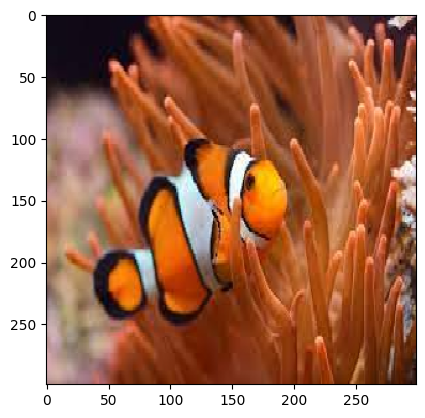

In [10]:
path_to_image = "anemone.jpg"
images = transform_images([path_to_image])
plt.figure()
plt.imshow(images[0] / 2 + 0.5)
plt.show()

### Predicción en la imagen de prueba

In [11]:
y_pred = model.predict(images)
y_pred.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


(1, 1000)

In [12]:
#anemone_fish: pez de las anémonas o pez payaso
#sea_anemone:  anémona de mar
#coral_reef:   arrecife de coral
#rock_beauty:  Rock Beauty Fish
#scuba_diver:  buceador
#sea_urchin:   erizo de mar

for x in decode_predictions(y_pred, top=6)[0]:
    print(f"Clase: {x[1]:<12} - Probabilidad: {x[2]:.2f}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Clase: anemone_fish - Probabilidad: 0.67
Clase: sea_anemone  - Probabilidad: 0.23
Clase: coral_reef   - Probabilidad: 0.02
Clase: rock_beauty  - Probabilidad: 0.00
Clase: scuba_diver  - Probabilidad: 0.00
Clase: sea_urchin   - Probabilidad: 0.00


## LimeImageExplainer

En la siguiente [documentación](https://lime-ml.readthedocs.io/en/latest/lime.html?highlight=submodular_pick#module-lime.lime_image) se detallan las clases y métodos utilizados a continuación.


In [13]:
explainer = lime_image.LimeImageExplainer()

In [14]:
explanation = explainer.explain_instance(
    images[0],
    model,
    top_labels=6,
    hide_color=0,
    num_samples=1000,
)

  0%|          | 0/1000 [00:00<?, ?it/s]

### Superpixeles generados

In [15]:
explanation.segments.max()

np.int64(64)

In [16]:
explanation.segments

array([[ 3,  3,  3, ...,  5,  5,  5],
       [ 3,  3,  3, ...,  5,  5,  5],
       [ 3,  3,  3, ...,  5,  5,  5],
       ...,
       [64, 64, 64, ..., 58, 58, 58],
       [64, 64, 64, ..., 58, 58, 58],
       [64, 64, 64, ..., 58, 58, 58]])

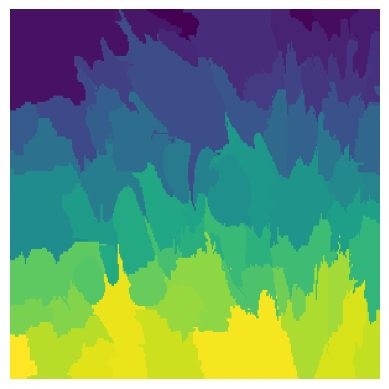

In [17]:
plt.imshow(explanation.segments)
plt.axis('off')
plt.show()

### Superpixeles que contribuyen positivamente a la predicción de la clase indicada

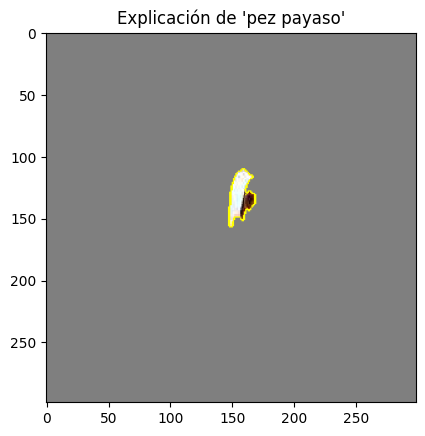

In [22]:
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    num_features=1,
    hide_rest=True,
)

plt.figure()
plt.title("Explicación de 'pez payaso'")
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.show()

In [1]:
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=False,
    num_features=10,
    hide_rest=False,
)
plt.figure()
plt.title("Explicación de 'pez payaso'")
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.show()

NameError: name 'explanation' is not defined

### Segmentación de los superpixeles que contribuyen positivamente a la predicción de la clase indicada

In [ ]:
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
)

plt.figure()
plt.title("Explicación de 'pez payaso'")
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.show()

### Visualización de los pesos en un mapa de calor

Para esta explicación, ``explanation.local_exp`` es un diccionario de tamaño 6. Cada clave corresponde a una de las 6 clases, y su valor es una lista que contiene los pesos de cada superpíxel.

In [ ]:
# Seleccionar el índice de la clase más probable
top_class_index = explanation.top_labels[0]

# Extraer los pesos asociados a cada superpixel de la explicación
class_weights = explanation.local_exp[top_class_index]

# Crear un diccionario que mapea los superpixeles a sus pesos
superpixel_weights = dict(class_weights)

# Mapear los pesos a los superpixeles para generar un mapa de calor
heatmap = np.vectorize(superpixel_weights.get)(explanation.segments)

plt.figure()
plt.imshow(heatmap, cmap='RdBu', vmin=-heatmap.max(), vmax=heatmap.max())
plt.colorbar(label='Peso')
plt.title('Pesos de los superpixeles')
plt.show()


## Ejercicio
1. Descarge la imagen usando:


!gdown "https://drive.google.com/file/d/1fpycjJxvEyOwBHI-xGGkf49FwLemMVCX/view?usp=sharing"


2. Genere la clasificación usando la CNN Inception V3 y explique (de acuerdo a los ejemplos anteriores) las cuatro primeras clasificaciones entregadas por la CNN.</li>
3. Analice la predicción genererada por el clasificador (puntaje/score) y las explicaciones para cada clase generada por LIME. Comente